In [ ]:
# Install Gurobi
!pip install gurobipy

# Import the Gurobi Package
import gurobipy as gp
from gurobipy import GRB

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 52.9 MB/s eta 0:00:00


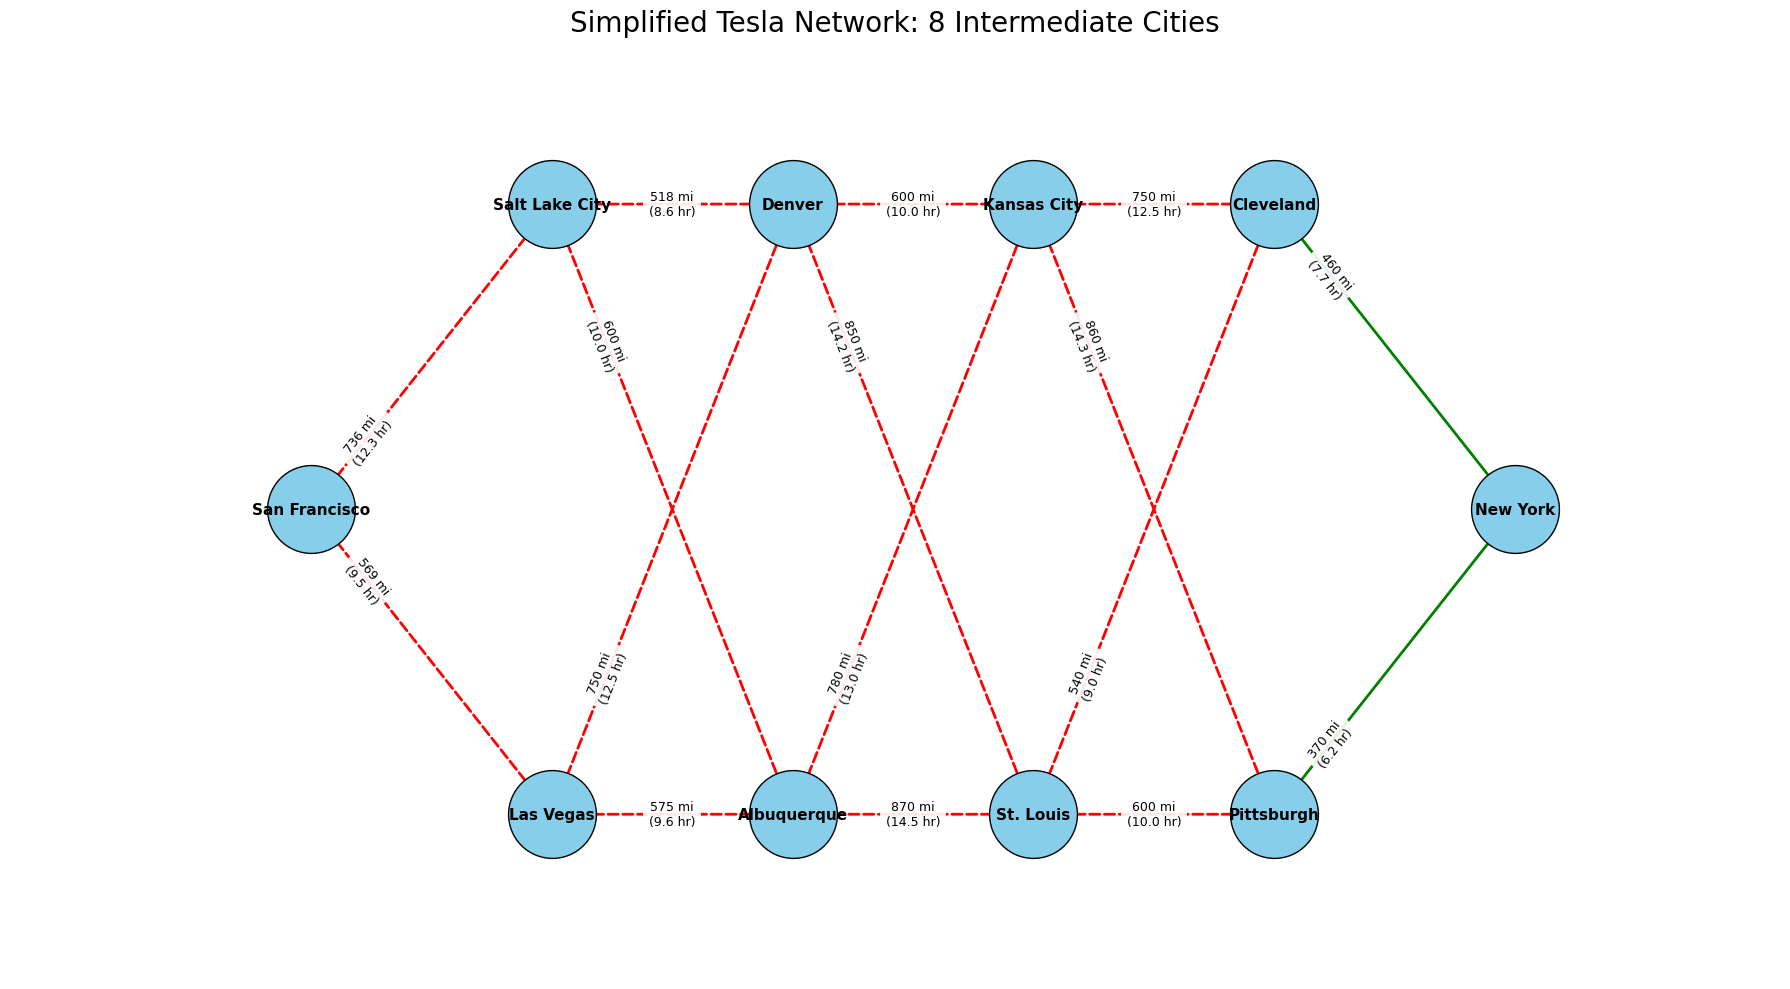

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def create_simple_network():
    G = nx.DiGraph()

    # --- 1. Define Nodes (10 Total) ---
    pos = {
        "San Francisco": (0, 2),
        "Salt Lake City": (1, 4),
        "Las Vegas": (1, 0),
        "Denver": (2, 4),
        "Albuquerque": (2, 0),
        "Kansas City": (3, 4),
        "St. Louis": (3, 0),
        "Cleveland": (4, 4),
        "Pittsburgh": (4, 0),
        "New York": (5, 2)
    }

    G.add_nodes_from(pos.keys())

    # --- 2. Define Edges and Distances (Miles) ---
    edges = [
        # From SF
        ("San Francisco", "Salt Lake City", 736),
        ("San Francisco", "Las Vegas", 569),
        # Stage 1
        ("Salt Lake City", "Denver", 518),
        ("Salt Lake City", "Albuquerque", 600), # Cross
        ("Las Vegas", "Denver", 750),           # Cross
        ("Las Vegas", "Albuquerque", 575),
        # Stage 2
        ("Denver", "Kansas City", 600),
        ("Denver", "St. Louis", 850),           # Cross
        ("Albuquerque", "Kansas City", 780),    # Cross
        ("Albuquerque", "St. Louis", 870),
        # Stage 3
        ("Kansas City", "Cleveland", 750),
        ("Kansas City", "Pittsburgh", 860),     # Cross
        ("St. Louis", "Cleveland", 540),        # Cross
        ("St. Louis", "Pittsburgh", 600),
        # Stage 4
        ("Cleveland", "New York", 460),
        ("Pittsburgh", "New York", 370)
    ]

    for u, v, w in edges:
        G.add_edge(u, v, weight=w)

    # --- 3. Visualization ---
    plt.figure(figsize=(18, 10))

    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_size=4000, node_color='#87CEEB', edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold')

    # Draw Edges
    feasible_edges = [(u, v) for u, v, w in edges if w <= 500]
    long_edges = [(u, v) for u, v, w in edges if w > 500]

    nx.draw_networkx_edges(G, pos, edgelist=feasible_edges, edge_color='green', width=2, arrowsize=25)
    nx.draw_networkx_edges(G, pos, edgelist=long_edges, edge_color='red', style='dashed', width=2, arrowsize=25)

    # --- 4. Improved Label Positioning ---
    # Separate edges into straight and crossing
    straight_edges = []
    crossing_edges = []

    for u, v, w in edges:
        # If the Y-coordinate is different, it's a crossing edge
        if pos[u][1] != pos[v][1]:
            crossing_edges.append((u, v, w))
        else:
            straight_edges.append((u, v, w))

    # 1. Labels for Straight Edges (Place in Middle: 0.5)
    straight_labels = {(u, v): f"{w} mi\n({w/60:.1f} hr)" for u, v, w in straight_edges}
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=straight_labels,
        label_pos=0.5,  # Center of the line
        font_size=9,
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='none')
    )

    # 2. Labels for Crossing Edges (Place near Source: 0.22)
    # This moves the label away from the "X" intersection point so they don't overlap or confuse.
    # It will appear closer to the city the truck is LEAVING.
    crossing_labels = {(u, v): f"{w} mi\n({w/60:.1f} hr)" for u, v, w in crossing_edges}
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=crossing_labels,
        label_pos=0.22,  # 22% distance from source node
        font_size=9,
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='none')
    )

    plt.title("Simplified Tesla Network: 8 Intermediate Cities", fontsize=20)
    plt.margins(0.2)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    create_simple_network()

In [ ]:

# --- 1. Define Model Data ---

# The arcs are defined as tuples (origin, destination).
# The associated values are the drive time in hours, as the objective is to MINIMIZE TIME.

# Decision Variable Abbreviations:
# XSF: San Francisco, XSL: Salt Lake City, XLV: Las Vegas, XD: Denver,
# XAL: Albuquerque, XKC: Kansas City, XLS: St. Louis, XCL: Cleveland,
# XP: Pittsburgh, XNY: New York

arcs, travel_times = gp.multidict({
    ('SF', 'SL'): 12.27,
    ('SF', 'LV'): 9.48,
    ('SL', 'D'): 8.63,
    ('SL', 'AL'): 10.00,
    ('LV', 'D'): 12.50,
    ('LV', 'AL'): 9.58,
    ('D', 'KC'): 10.00,
    ('D', 'LS'): 14.17,
    ('AL', 'KC'): 13.00,
    ('AL', 'LS'): 14.50,
    ('KC', 'CL'): 12.50,
    ('KC', 'P'): 14.33,
    ('LS', 'CL'): 9.00,
    ('LS', 'P'): 10.00,
    ('CL', 'NY'): 7.67,
    ('P', 'NY'): 6.17
})

# Find all unique nodes from the arcs
nodes = sorted(list(set([i for i, j in arcs] + [j for i, j in arcs])))

# --- 2. Objective Function (Verification) ---
# When using the travel time data (in hours), the objective function to minimize time is:
# MIN: 12.27 XSF, SL + 9.48 XSF, LV + 8.63 XSL, D + 10.00 XSL, AL + 12.50 XLV, D + 9.58 XLV, AL +
#      10.00 XD, KC + 14.17 XD, LS + 13.00 XAL, KC + 14.50 XAL, LS + 12.50 XKC, CL + 14.33 XKC, P +
#      9.00 XLS, CL + 10.00 XLS, P + 7.67 XCL, NY + 6.17 XP, NY

# Find all unique nodes from the arcs
nodes = sorted(list(set([i for i, j in arcs] + [j for i, j in arcs])))
origin_node = 'SF'
destination_node = 'NY'

**Step 3: Set up the Linear Programming Model**

In [ ]:
# --- 2. Create the Gurobi Model ---
m = gp.Model("Shortest_Path")

# --- 3. Add Decision Variables ---
# A binary variable for each arc indicates if it's on the path
x = m.addVars(arcs, name="path")

# --- 4. Define the Objective Function using gp.quicksum ---
# Minimize the total distance of the selected path
objective = gp.quicksum(x[i, j] * travel_times[i, j] for i, j in arcs)
m.setObjective(objective, GRB.MINIMIZE)

# --- 5. Add Constraints (Flow Balance) using gp.quicksum ---
for n in nodes:
    # Sum of flows out of node n
    flow_out = gp.quicksum(x[i, j] for i, j in arcs if i == n)
    # Sum of flows into node n
    flow_in = gp.quicksum(x[i, j] for i, j in arcs if j == n)

    if n == origin_node:
        # Net flow at the origin must be 1
        m.addConstr(flow_out - flow_in == 1, name=f"Flow_{n}")
    elif n == destination_node:
        # Net flow at the destination must be -1
        m.addConstr(flow_out - flow_in == -1, name=f"Flow_{n}")
    else:
        # Flow is conserved at intermediate nodes (flow in = flow out)
        m.addConstr(flow_out - flow_in == 0, name=f"Flow_{n}")


Restricted license - for non-production use only - expires 2027-11-29


**Step 4: Solve the Model and Display Output**

In [ ]:
# --- 6. Solve the Model ---
m.optimize()

# --- 7. Print the Solution ---
if m.status == GRB.OPTIMAL:
    print(f"\nShortest Path Distance: {m.objVal:,.2f} driving hours")

    # Find and print the path
    print("\nPath:")
    current_node = origin_node
    path_str = current_node

    # Reconstruct the path by following the selected arcs
    while current_node != destination_node:
        for i, j in arcs:
            if i == current_node and x[i, j].X > 0.5:
                path_str += f" -> {j}"
                current_node = j
                break
    print(path_str)

else:
    print("No optimal solution found.")

Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: AMD EPYC 7B12, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 10 rows, 16 columns and 32 nonzeros (Min)
Model fingerprint: 0xd33cc556
Model has 16 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [6e+00, 1e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 4 rows and 4 columns
Presolve time: 0.01s
Presolved: 6 rows, 12 columns, 24 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    2.5230000e+01   2.000000e+00   0.000000e+00      0s
       4    4.9730000e+01   0.000000e+00   0.000000e+00      0s

Solved in 4 iterations and 0.03 seconds (0.00 work units)
Optimal objective  4.973000000e+01

Shortest Path Distance: 49.73 driving hours

Path:
SF -> LV -> AL -> LS -> P -> NY


In [ ]:
#Diagram here

## Visualize Optimal Path

### Subtask:
Generate Python code using NetworkX and Matplotlib to plot the shortest path found.


**Reasoning**:
Generate Python code to visualize the shortest path using NetworkX and Matplotlib as per the detailed instructions.



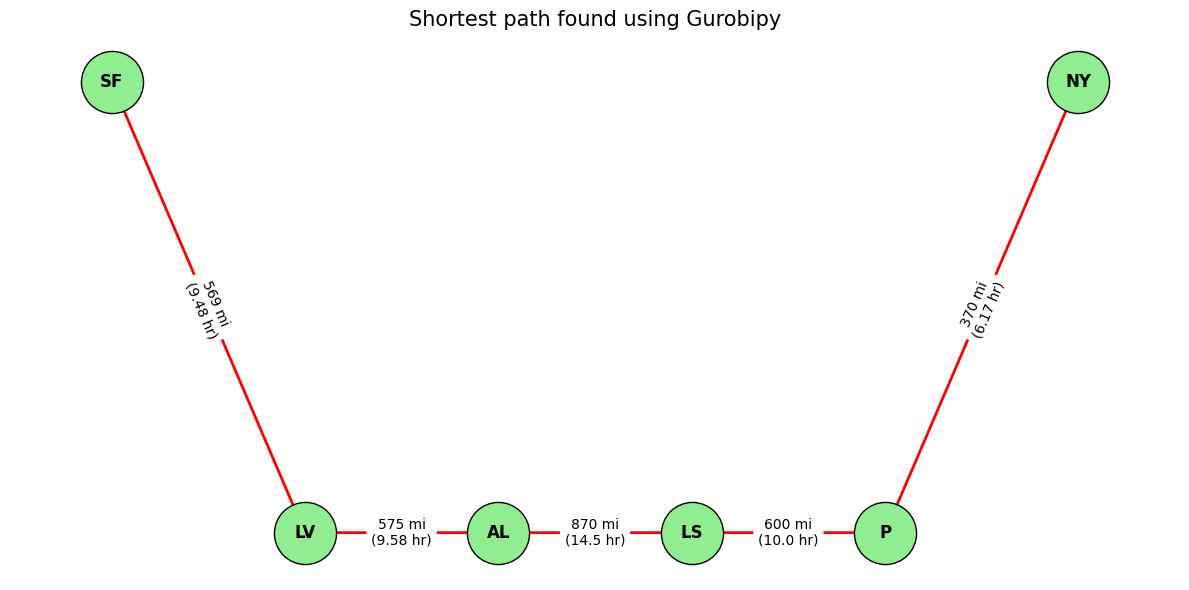

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Initialize a new directed graph G
G = nx.DiGraph()

# 2. Define the positions for the nodes
pos = {'SF': (0, 2), 'LV': (1, 0), 'AL': (2, 0), 'LS': (3, 0), 'P': (4, 0), 'NY': (5, 2)}

# 3. Add the edges to the graph corresponding to the shortest path
# Include 'miles' and 'hours' as attributes
edges_data = [
    ('SF', 'LV', {'miles': 569, 'hours': 9.48}),
    ('LV', 'AL', {'miles': 575, 'hours': 9.58}),
    ('AL', 'LS', {'miles': 870, 'hours': 14.50}),
    ('LS', 'P', {'miles': 600, 'hours': 10.00}),
    ('P', 'NY', {'miles': 370, 'hours': 6.17})
]
G.add_edges_from(edges_data)

# 4. Configure the plot and draw nodes/edges
plt.figure(figsize=(12, 6))

# Draw nodes with light green color
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightgreen', edgecolors='black')

# Draw edges with red color
nx.draw_networkx_edges(G, pos, edge_color='red', width=2, arrowsize=20)

# 5. Create and draw edge labels
edge_labels = {(u, v): f"{d['miles']} mi\n({d['hours']} hr)" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

# 6. Add node labels and final touches
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
plt.title("Shortest path found using Gurobipy", fontsize=15)
plt.axis('off')
plt.tight_layout()
plt.show()

## Summary:

### Q&A
**Question:** What specific route constitutes the shortest path visualized in the analysis?
**Answer:** The visualized path is a directed route starting at **SF** and ending at **NY**, passing through **LV**, **AL**, **LS**, and **P** in that specific sequence.

### Data Analysis Key Findings
*   **Path Composition**: The graph successfully visualized a multi-stage journey with the following specific segment attributes:
    *   **SF to LV**: 569 mi (9.48 hr)
    *   **LV to AL**: 575 mi (9.58 hr)
    *   **AL to LS**: 870 mi (14.50 hr)
    *   **LS to P**: 600 mi (10.00 hr)
    *   **P to NY**: 370 mi (6.17 hr)
*   **Spatial Layout**: The network was constructed as a directed graph using fixed coordinates to represent relative positions, effectively showing a progression from the starting point at `(0, 2)` to the destination at `(5, 2)`.
*   **Visual Styling**: The plot was rendered with high-contrast styling—light green nodes and red edges—and included formatted text labels to simultaneously display both mileage and hourly duration for every edge.

### Insights or Next Steps
*   **Bottleneck Identification**: Visual inspection of the edge data reveals that the leg between **AL and LS** is the most resource-intensive segment, accounting for 870 miles and 14.50 hours alone.
*   **Future Analysis**: A potential next step is to compute the cumulative metrics (total distance and total time) based on the visualized path or to overlay this optimal path against other potential routes to demonstrate the efficiency of the solution found by Gurobi.
